### Подготовка данных и загрузка аннотаций
В этом блоке импортируются необходимые библиотеки и загружаются Ground Truth аннотации датасета COCO val2017. Это базовый шаг для последующего сравнения предсказаний моделей с эталоном.

In [3]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

ANN_PATH = "../datasets/coco/annotations/instances_val2017.json"
PRED_DIR = "predictions"

print("Загрузка Ground Truth аннотаций...")
cocoGT = COCO(ANN_PATH)
print("Успешно!")

Загрузка Ground Truth аннотаций...
loading annotations into memory...
Done (t=0.41s)
creating index...
index created!
Успешно!


### График 1: Распределение классов в датасете 
Данный скрипт подсчитывает количество объектов каждого класса в валидационной выборке COCO и строит столбчатую диаграмму (Barplot). Для наглядности выводятся 20 самых часто встречающихся и 20 самых редких классов. График позволяет визуально оценить степень дисбаланса данных (например, колоссальное доминирование класса `person` по сравнению с остальными).


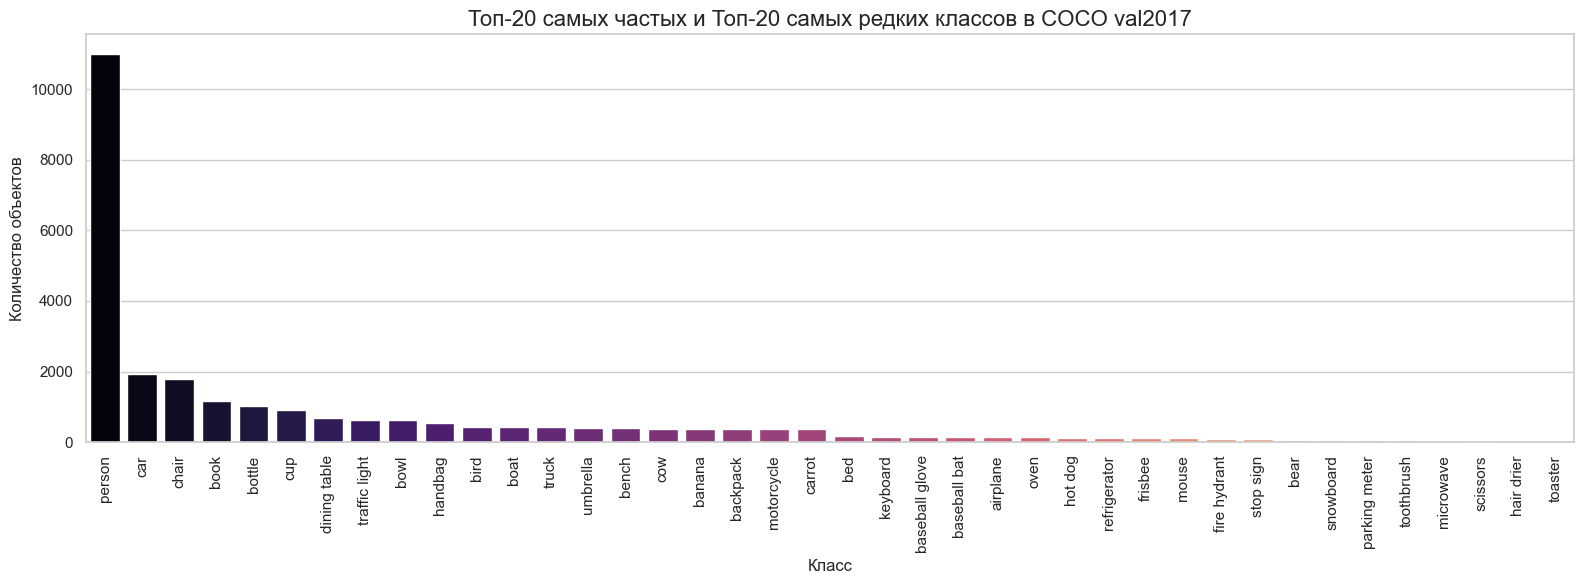

In [5]:
def get_class_distribution(coco):
    cats = coco.loadCats(coco.getCatIds())
    class_names = []
    class_counts = []
    
    for cat in cats:
        annIds = coco.getAnnIds(catIds=[cat['id']])
        class_names.append(cat['name'])
        class_counts.append(len(annIds))
        
    df = pd.DataFrame({'Class': class_names, 'Count': class_counts})
    df = df.sort_values('Count', ascending=False)
    return df

df_dist = get_class_distribution(cocoGT)

plt.figure(figsize=(16, 6))
df_plot = pd.concat([df_dist.head(20), df_dist.tail(20)])

sns.barplot(x='Class', y='Count', data=df_plot, palette='magma')
plt.title('Топ-20 самых частых и Топ-20 самых редких классов в COCO val2017', fontsize=16)
plt.xticks(rotation=90)
plt.ylabel('Количество объектов')
plt.xlabel('Класс')
plt.tight_layout()
plt.show()

### Расчет метрик (Оценка предсказаний моделей)
Здесь происходит парсинг JSON-файлов с предсказаниями различных моделей (семейства YOLO, YOLOX, DEIM различных размеров). Для каждой модели и для каждого класса с помощью API `pycocotools` рассчитывается метрика Average Precision (mAP 50-95). Результаты собираются в единый DataFrame и сохраняются в CSV-файл, чтобы не пересчитывать их при каждом запуске.

In [7]:
def extract_model_info(filename):
    """Извлекает имя, семейство и размер из названия файла."""
    base_name = os.path.basename(filename).replace('predictions_', '').replace('.json', '')
    
    # Последний символ - это обычно размер (n, s, m, l, x, c, t)
    size = base_name[-1]
    family = base_name[:-1]
    
    return base_name, family, size

def evaluate_all_models(cocoGT, pred_dir):
    json_files = glob.glob(os.path.join(pred_dir, "predictions_*.json"))
    all_results = []
    
    catIds = cocoGT.getCatIds()
    cats = cocoGT.loadCats(catIds)
    cat_names = [c['name'] for c in cats]
    
    print(f"Найдено {len(json_files)} файлов предсказаний. Начинаем расчет (это может занять время)...")
    
    for file in json_files:
        model_name, family, size = extract_model_info(file)
        print(f"Оценка: {model_name}...")
        
        try:
            cocoDT = cocoGT.loadRes(file)
            cocoEval = COCOeval(cocoGT, cocoDT, 'bbox')
            cocoEval.evaluate()
            cocoEval.accumulate()
            
            precision = cocoEval.eval['precision']
            
            for i, cat_id in enumerate(catIds):
                pr_all_iou = precision[:, :, i, 0, 2] 
                pr_all_iou = pr_all_iou[pr_all_iou > -1]
                ap_50_95 = np.mean(pr_all_iou) if len(pr_all_iou) > 0 else np.nan
                
                all_results.append({
                    'Model': model_name,
                    'Family': family,
                    'Size': size,
                    'Class': cat_names[i],
                    'AP50-95': ap_50_95
                })
        except Exception as e:
            print(f"Ошибка при обработке {model_name}: {e}")
            
    return pd.DataFrame(all_results).dropna()

df_metrics = evaluate_all_models(cocoGT, PRED_DIR)
df_metrics.to_csv('per_class_metrics_all_models.csv', index=False) 
print("Расчет завершен и сохранен!")

try:
    df_metrics = pd.read_csv('per_class_metrics_all_models.csv')
    print("Данные успешно загружены из файла!")
except FileNotFoundError:
    df_metrics = evaluate_all_models(cocoGT, PRED_DIR)
    df_metrics.to_csv('per_class_metrics_all_models.csv', index=False)

Найдено 24 файлов предсказаний. Начинаем расчет (это может занять время)...
Оценка: LibreYOLO9t...
Loading and preparing results...
DONE (t=3.90s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=34.13s).
Accumulating evaluation results...
DONE (t=7.09s).
Оценка: LibreYOLOXs...
Loading and preparing results...
DONE (t=7.46s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=34.28s).
Accumulating evaluation results...
DONE (t=10.16s).
Оценка: LibreYOLO9m...
Loading and preparing results...
DONE (t=9.47s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=38.09s).
Accumulating evaluation results...
DONE (t=4.78s).
Оценка: LibreYOLO9E2Em...
Loading and preparing results...
DONE (t=2.75s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=25.77s).
Accumulating evaluation res

### График 2: Рейтинг сложности классов
Код усредняет метрику AP50-95 для каждого класса *по всем протестированным моделям*. Затем строятся два горизонтальных барплота: слева — 15 объектов, которые детекторы распознают лучше всего (самые легкие), справа — 15 объектов, с которыми алгоритмы справляются хуже всего (самые сложные).

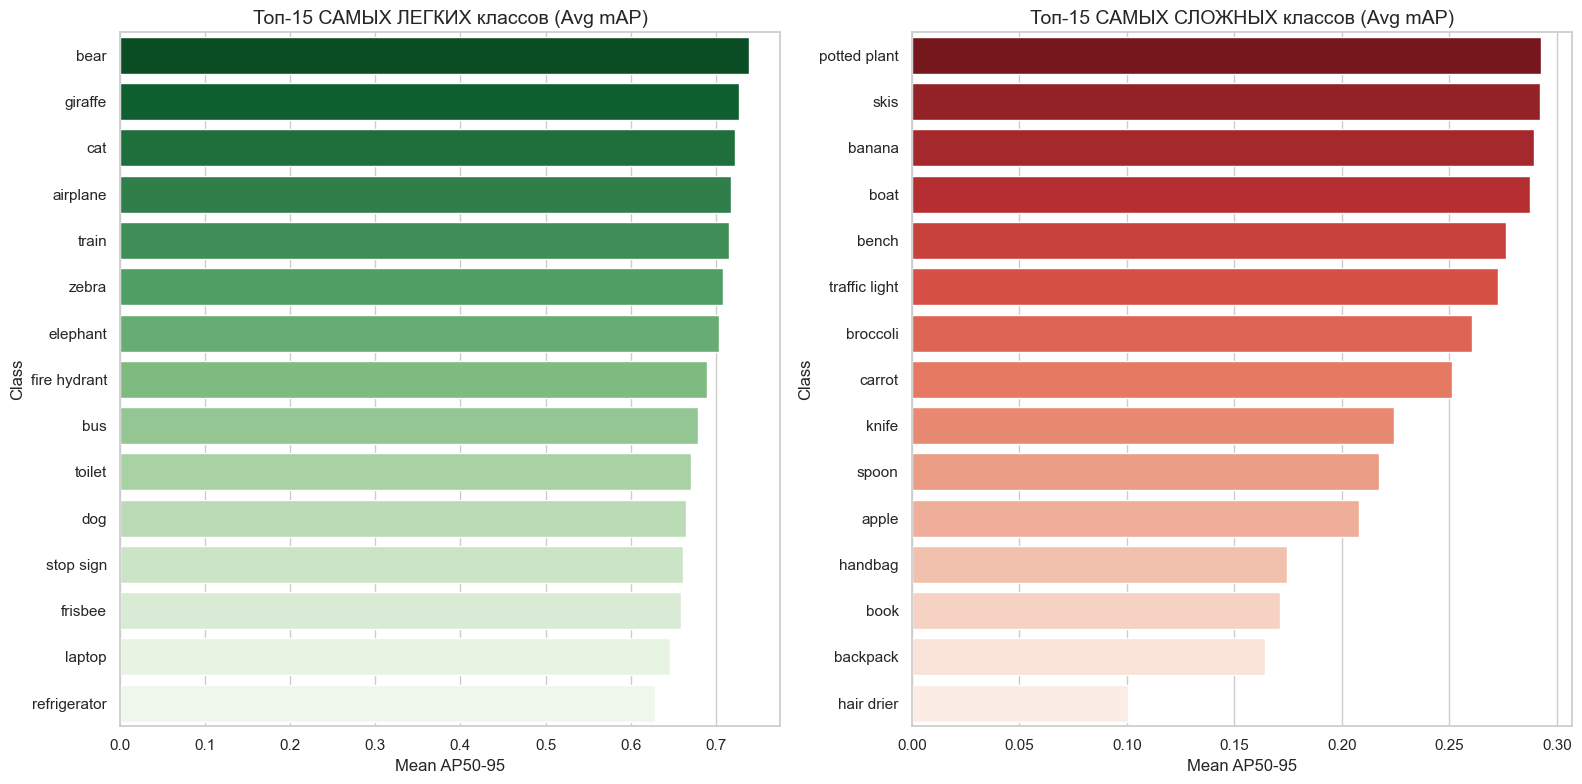

In [11]:
class_difficulty = df_metrics.groupby('Class')['AP50-95'].mean().reset_index()
class_difficulty = class_difficulty.sort_values('AP50-95', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(x='AP50-95', y='Class', data=class_difficulty.head(15), ax=axes[0], palette='Greens_r')
axes[0].set_title('Топ-15 САМЫХ ЛЕГКИХ классов (Avg mAP)', fontsize=14)
axes[0].set_xlabel('Mean AP50-95')

sns.barplot(x='AP50-95', y='Class', data=class_difficulty.tail(15), ax=axes[1], palette='Reds_r')
axes[1].set_title('Топ-15 САМЫХ СЛОЖНЫХ классов (Avg mAP)', fontsize=14)
axes[1].set_xlabel('Mean AP50-95')

plt.tight_layout()
plt.show()

### График 3: Тепловая карта (Heatmap) точности моделей
**Что делает этот график:**
Скрипт отбирает 20 самых частых классов датасета (на которых собрано больше всего данных) и строит тепловую карту. По оси Y расположены модели (отсортированные по убыванию их средней точности), по оси X — классы. Цветом и числовыми значениями показана метрика AP50-95 конкретной модели на конкретном классе. Это позволяет детально сравнить, какие архитектуры лучше справляются с базовыми объектами.

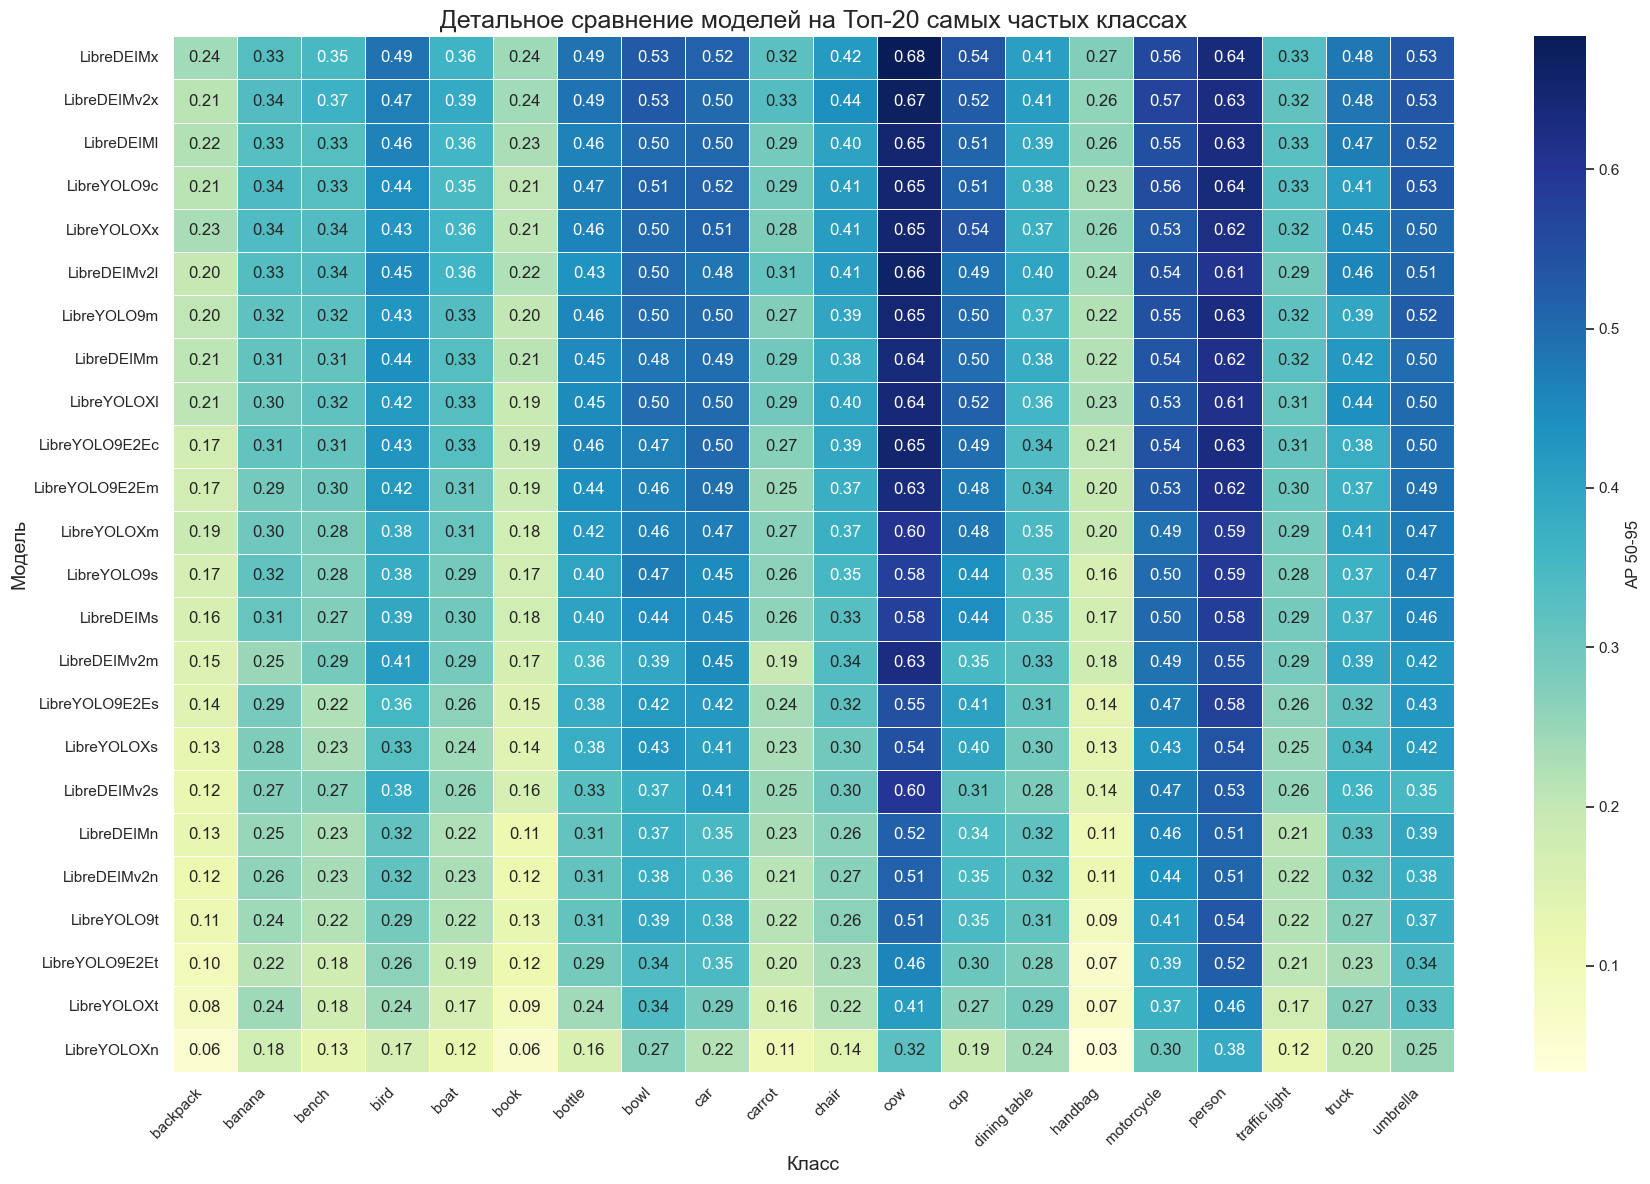

In [13]:
top_classes = df_dist['Class'].head(20).tolist()

df_heatmap = df_metrics[df_metrics['Class'].isin(top_classes)]
pivot_df = df_heatmap.pivot(index='Model', columns='Class', values='AP50-95')

pivot_df['Mean'] = pivot_df.mean(axis=1)
pivot_df = pivot_df.sort_values('Mean', ascending=False).drop(columns=['Mean'])

plt.figure(figsize=(18, 12))
sns.heatmap(pivot_df, cmap='YlGnBu', annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'AP 50-95'})
plt.title('Детальное сравнение моделей на Топ-20 самых частых классах', fontsize=18)
plt.ylabel('Модель', fontsize=14)
plt.xlabel('Класс', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### График 4: Влияние объема данных на точность детекции
Код находит самую точную модель (в данном случае `LibreDEIMv2x`) и исследует гипотезу: "Чем больше примеров класса в датасете, тем лучше модель его распознает". Строится диаграмма рассеяния, где по оси X — количество объектов класса (в логарифмическом масштабе из-за выброса в виде класса `person`), а по оси Y — точность AP50-95. Также добавляется линия тренда и вычисляется коэффициент корреляции Пирсона.

Лучшая модель по общему mAP: LibreDEIMv2x


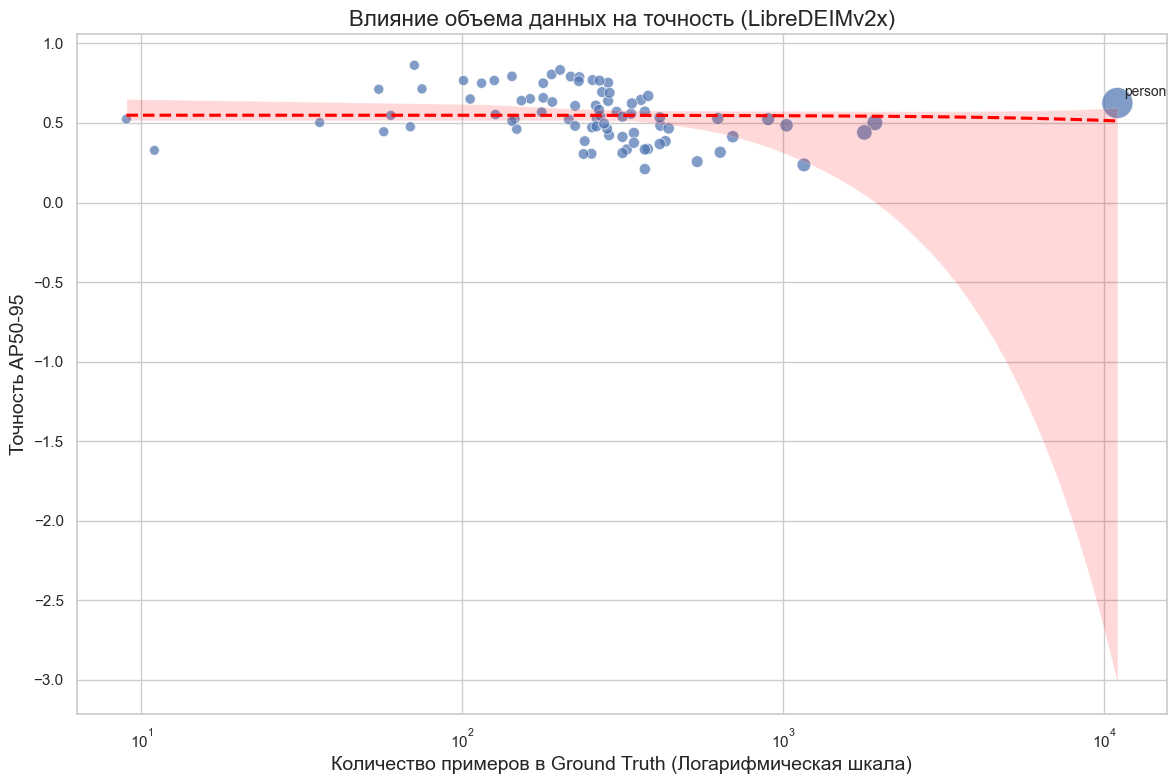

Корреляция между количеством примеров и точностью: -0.026


In [15]:
best_model_name = df_overall.sort_values('AP50-95', ascending=False).iloc[0]['Model']
print(f"Лучшая модель по общему mAP: {best_model_name}")

df_best_model = df_metrics[df_metrics['Model'] == best_model_name]

df_corr = pd.merge(df_best_model, df_dist, on='Class')

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_corr, x='Count', y='AP50-95', size='Count', sizes=(50, 500), alpha=0.7, color='b', legend=False)

sns.regplot(data=df_corr, x='Count', y='AP50-95', scatter=False, color='red', line_kws={"linestyle": "--"})

for i, row in df_corr.iterrows():
    if row['AP50-95'] < 0.2 or row['Count'] > 10000:
        plt.annotate(row['Class'], (row['Count'], row['AP50-95']), xytext=(5, 5), textcoords='offset points', fontsize=10)

plt.xscale('log')
plt.title(f'Влияние объема данных на точность ({best_model_name})', fontsize=16)
plt.xlabel('Количество примеров в Ground Truth (Логарифмическая шкала)', fontsize=14)
plt.ylabel('Точность AP50-95', fontsize=14)
plt.tight_layout()
plt.show()

corr = df_corr['Count'].corr(df_corr['AP50-95'])
print(f"Корреляция между количеством примеров и точностью: {corr:.3f}")

### Общий аналитический вывод

На основе проведенного анализа предсказаний моделей на датасете COCO val2017 можно сделать следующие ключевые выводы:

1. **Экстремальный дисбаланс данных:** Датасет COCO характеризуется сильным перекосом в сторону класса `person` (более 10 000 объектов). Подавляющее большинство других классов представлены в десятки раз реже.
2. **Сложность объекта важнее количества данных:** Анализ самых "легких" и "сложных" классов (График 2) показывает, что сложность распознавания зависит от физических характеристик объекта. Легко распознаются крупные, визуально отличимые объекты (медведь, жираф, самолет). Плохо распознаются мелкие, тонкие или сильно перекрывающиеся объекты с размытыми границами (растение в горшке, лыжи, ложка, яблоко).
3. **Эволюция архитектур:** Тепловая карта (График 3) демонстрирует четкую иерархию качества моделей. Семейство `LibreDEIM` (особенно версии `v2x`, `x`, `v2l`) стабильно превосходит модели `LibreYOLO` и `LibreYOLOX` на большинстве частых классов. Тем не менее, даже лучшие модели "проседают" на контекстно-зависимых классах вроде `book` или `backpack`.
4. **Отсутствие прямой корреляции между объемом выборки и точностью:** Пожалуй, самый интересный инсайт дает График 4. Коэффициент корреляции составил **-0.026**, что говорит о полном отсутствии линейной зависимости. Наличие огромного числа примеров (как в случае с классом `person`) не делает его самым легко распознаваемым классом. Точность упирается не в количество картинок, а в изменчивость ракурсов, масштаб объектов, освещение и качество самих аннотаций.